In [1]:
import os
import pandas as pd
import numpy as np
import time

from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.api import VAR

import traceback
import psutil as ps
import warnings
warnings.filterwarnings("ignore")

In [2]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/data/processed")
weather_data = pd.read_csv("clean_weather_data.csv", parse_dates = ["Date"])
weather_data.head()

,Date,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day,Rolling Mean of Temperature,...,Rolling Mean of Wind_speed,Rolling Mean of Surface_pressure,Rolling Mean of Pressure_msl,Rolling std of Temperature,Rolling std of Relative_humidity,Rolling std of Rain,Rolling std of Soil_temperature,Rolling std of Wind_speed,Rolling std of Surface_pressure,Rolling std of Pressure_msl
0,2020-01-01 23:00:00,10.3,95,0.0,11.7,17.0,1007.0,1021.7,0,11.629167,...,13.670833,1006.070833,1020.645833,4.800225,12.261345,0.065801,3.417514,2.702572,1.337252,1.297482
1,2020-01-02 00:00:00,10.8,94,0.0,11.4,20.0,1006.7,1021.3,0,11.837500,...,13.875000,1006.162500,1020.725000,4.642133,12.293438,0.065801,3.352730,2.985508,1.299770,1.275948
2,2020-01-02 01:00:00,10.4,95,0.0,11.2,18.4,1006.3,1020.9,0,12.033333,...,14.037500,1006.241667,1020.791667,4.467824,12.360453,0.065801,3.268326,3.123935,1.244437,1.239536
3,2020-01-02 02:00:00,10.3,95,0.0,11.0,18.9,1006.2,1020.8,0,12.212500,...,14.295833,1006.308333,1020.850000,4.298363,12.426523,0.065801,3.167075,3.261832,1.194523,1.203618
4,2020-01-02 03:00:00,9.8,96,0.0,10.8,18.1,1005.6,1020.3,0,12.379167,...,14.537500,1006.350000,1020.883333,4.112439,12.498623,0.065801,3.047296,3.321840,1.148913,1.175351


In [3]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52585 entries, 0 to 52584
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Date                               52585 non-null  datetime64[ns]
 1   Temperature                        52585 non-null  float64       
 2   Relative_humidity                  52585 non-null  int64         
 3   Rain                               52585 non-null  float64       
 4   Soil_temperature                   52585 non-null  float64       
 5   Wind_speed                         52585 non-null  float64       
 6   Surface_pressure                   52585 non-null  float64       
 7   Pressure_msl                       52585 non-null  float64       
 8   is_day                             52585 non-null  int64         
 9   Rolling Mean of Temperature        52585 non-null  float64       
 10  Rolling Mean of Relative_humidity 

In [4]:
weather_data.set_index("Date",inplace = True)

In [5]:
rm_cols = [col for col in weather_data.columns if "std" or "is_" in col]
weather_data.drop(columns=rm_cols)

""
Date
2020-01-01 23:00:00
2020-01-02 00:00:00
2020-01-02 01:00:00
2020-01-02 02:00:00
2020-01-02 03:00:00
...
2025-12-31 19:00:00
2025-12-31 20:00:00
2025-12-31 21:00:00


In [6]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52585 entries, 2020-01-01 23:00:00 to 2025-12-31 23:00:00
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Temperature                        52585 non-null  float64
 1   Relative_humidity                  52585 non-null  int64  
 2   Rain                               52585 non-null  float64
 3   Soil_temperature                   52585 non-null  float64
 4   Wind_speed                         52585 non-null  float64
 5   Surface_pressure                   52585 non-null  float64
 6   Pressure_msl                       52585 non-null  float64
 7   is_day                             52585 non-null  int64  
 8   Rolling Mean of Temperature        52585 non-null  float64
 9   Rolling Mean of Relative_humidity  52585 non-null  float64
 10  Rolling Mean of Rain               52585 non-null  float64
 11  Rolling Mean of Soi

In [7]:
def causality_test(data):
    max_lag = 24
    
    result = grangercausalitytests(data, maxlag = max_lag, verbose = True)
    for lag in range(1, max_lag+1):
        p_value = result[lag][0]["ssr_ftest"][1]
        print(f"lag {lag : 2d}: P Value = {p_value : .5f}")
        
    alpha = 0.05

    for lag in range(1, max_lag + 1):
        p_value = result[lag][0]['ssr_ftest'][1]

        if p_value < alpha:
            print(f"Lag {lag}: Significant (p = {p_value:.5f})")
        else:
            print(f"Lag {lag}: Not Significant (p = {p_value:.5f})")

In [8]:
causality_test(weather_data[["Temperature", "Relative_humidity"]])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=651.9582, p=0.0000  , df_denom=52581, df_num=1
ssr based chi2 test:   chi2=651.9953, p=0.0000  , df=1
likelihood ratio test: chi2=647.9864, p=0.0000  , df=1
parameter F test:         F=651.9582, p=0.0000  , df_denom=52581, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=810.3506, p=0.0000  , df_denom=52578, df_num=2
ssr based chi2 test:   chi2=1620.8553, p=0.0000  , df=2
likelihood ratio test: chi2=1596.3758, p=0.0000  , df=2
parameter F test:         F=810.3506, p=0.0000  , df_denom=52578, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=837.2655, p=0.0000  , df_denom=52575, df_num=3
ssr based chi2 test:   chi2=2512.1309, p=0.0000  , df=3
likelihood ratio test: chi2=2453.9671, p=0.0000  , df=3
parameter F test:         F=837.2655, p=0.0000  , df_denom=52575, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=648.

In [9]:
causality_test(weather_data[["Temperature", "Rain"]])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.3417  , p=0.2467  , df_denom=52581, df_num=1
ssr based chi2 test:   chi2=1.3418  , p=0.2467  , df=1
likelihood ratio test: chi2=1.3418  , p=0.2467  , df=1
parameter F test:         F=1.3417  , p=0.2467  , df_denom=52581, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=327.0312, p=0.0000  , df_denom=52578, df_num=2
ssr based chi2 test:   chi2=654.1246, p=0.0000  , df=2
likelihood ratio test: chi2=650.0894, p=0.0000  , df=2
parameter F test:         F=327.0312, p=0.0000  , df_denom=52578, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=196.6525, p=0.0000  , df_denom=52575, df_num=3
ssr based chi2 test:   chi2=590.0361, p=0.0000  , df=3
likelihood ratio test: chi2=586.7502, p=0.0000  , df=3
parameter F test:         F=196.6525, p=0.0000  , df_denom=52575, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=150.2150

In [10]:
causality_test(weather_data[["Temperature", "Soil_temperature"]])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=4113.0903, p=0.0000  , df_denom=52581, df_num=1
ssr based chi2 test:   chi2=4113.3250, p=0.0000  , df=1
likelihood ratio test: chi2=3960.3714, p=0.0000  , df=1
parameter F test:         F=4113.0903, p=0.0000  , df_denom=52581, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2277.8607, p=0.0000  , df_denom=52578, df_num=2
ssr based chi2 test:   chi2=4556.1547, p=0.0000  , df=2
likelihood ratio test: chi2=4369.4754, p=0.0000  , df=2
parameter F test:         F=2277.8607, p=0.0000  , df_denom=52578, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1707.8438, p=0.0000  , df_denom=52575, df_num=3
ssr based chi2 test:   chi2=5124.2136, p=0.0000  , df=3
likelihood ratio test: chi2=4889.6528, p=0.0000  , df=3
parameter F test:         F=1707.8438, p=0.0000  , df_denom=52575, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:       

In [11]:
causality_test(weather_data[["Temperature", "Wind_speed"]])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=733.2341, p=0.0000  , df_denom=52581, df_num=1
ssr based chi2 test:   chi2=733.2759, p=0.0000  , df=1
likelihood ratio test: chi2=728.2102, p=0.0000  , df=1
parameter F test:         F=733.2341, p=0.0000  , df_denom=52581, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=18.6406 , p=0.0000  , df_denom=52578, df_num=2
ssr based chi2 test:   chi2=37.2848 , p=0.0000  , df=2
likelihood ratio test: chi2=37.2716 , p=0.0000  , df=2
parameter F test:         F=18.6406 , p=0.0000  , df_denom=52578, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=41.6232 , p=0.0000  , df_denom=52575, df_num=3
ssr based chi2 test:   chi2=124.8861, p=0.0000  , df=3
likelihood ratio test: chi2=124.7380, p=0.0000  , df=3
parameter F test:         F=41.6232 , p=0.0000  , df_denom=52575, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=58.5481 

In [12]:
causality_test(weather_data[["Temperature", "Surface_pressure"]])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=498.8146, p=0.0000  , df_denom=52581, df_num=1
ssr based chi2 test:   chi2=498.8430, p=0.0000  , df=1
likelihood ratio test: chi2=496.4917, p=0.0000  , df=1
parameter F test:         F=498.8146, p=0.0000  , df_denom=52581, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1935.0945, p=0.0000  , df_denom=52578, df_num=2
ssr based chi2 test:   chi2=3870.5570, p=0.0000  , df=2
likelihood ratio test: chi2=3734.7300, p=0.0000  , df=2
parameter F test:         F=1935.0945, p=0.0000  , df_denom=52578, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2283.0021, p=0.0000  , df_denom=52575, df_num=3
ssr based chi2 test:   chi2=6849.9182, p=0.0000  , df=3
likelihood ratio test: chi2=6439.0639, p=0.0000  , df=3
parameter F test:         F=2283.0021, p=0.0000  , df_denom=52575, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=

In [13]:
causality_test(weather_data[["Temperature", "Pressure_msl"]])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=498.2695, p=0.0000  , df_denom=52581, df_num=1
ssr based chi2 test:   chi2=498.2979, p=0.0000  , df=1
likelihood ratio test: chi2=495.9517, p=0.0000  , df=1
parameter F test:         F=498.2695, p=0.0000  , df_denom=52581, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1944.1009, p=0.0000  , df_denom=52578, df_num=2
ssr based chi2 test:   chi2=3888.5716, p=0.0000  , df=2
likelihood ratio test: chi2=3751.5068, p=0.0000  , df=2
parameter F test:         F=1944.1009, p=0.0000  , df_denom=52578, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2283.8195, p=0.0000  , df_denom=52575, df_num=3
ssr based chi2 test:   chi2=6852.3707, p=0.0000  , df=3
likelihood ratio test: chi2=6441.2337, p=0.0000  , df=3
parameter F test:         F=2283.8195, p=0.0000  , df_denom=52575, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=

In [14]:
train_data = weather_data[:int(0.9*len(weather_data))]
test_data = weather_data[int(0.9*len(weather_data)):]

In [15]:
train_data.shape

(47326, 22)

In [16]:
test_data.shape

(5259, 22)

In [17]:
var_model = VAR(train_data)

In [18]:
lag_order = var_model.select_order(maxlags = 8)
lag_order.summary()

,AIC,BIC,FPE,HQIC
0,-10.07,-10.07,4.225e-05,-10.07
1,-94.96,-94.86,5.768e-42,-94.93
2,-112.5,-112.3,1.396e-49,-112.4
3,-113.7,-113.4,4.099e-50,-113.6
4,-114.0,-113.7,2.959e-50,-113.9
5,-114.3,-113.8,2.406e-50,-114.1
6,-114.4,-113.9,2.018e-50,-114.3
7,-114.6,-114.0,1.710e-50,-114.4
8,-114.8*,-114.0*,1.459e-50*,-114.5*


In [19]:
model_result = var_model.fit(maxlags = 12)
model_result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 09, Jul, 2026
Time:                     13:44:27
--------------------------------------------------------------------
No. of Equations:         22.0000    BIC:                   -114.556
Nobs:                     47314.0    HQIC:                  -115.297
Log likelihood:       1.26444e+06    FPE:                6.02509e-51
AIC:                     -115.636    Det(Omega_mle):     5.32844e-51
--------------------------------------------------------------------
Results for equation Temperature
                                           coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------------------------
const                                         3.713759         1.523734            2.437           0.015
L1.Temperature                                0.976531         

In [20]:
forecast = model_result.forecast(
    y=train_data.values[-12:],
    steps=len(test_data)
)

In [21]:
forecast_df = pd.DataFrame(
    forecast,
    index=test_data.index,
    columns=test_data.columns
)

forecast_df.head(5)

,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day,Rolling Mean of Temperature,Rolling Mean of Relative_humidity,...,Rolling Mean of Wind_speed,Rolling Mean of Surface_pressure,Rolling Mean of Pressure_msl,Rolling std of Temperature,Rolling std of Relative_humidity,Rolling std of Rain,Rolling std of Soil_temperature,Rolling std of Wind_speed,Rolling std of Surface_pressure,Rolling std of Pressure_msl
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-26 21:00:00,30.828773,61.413699,-0.004265,31.944486,21.001042,986.521655,999.894993,0.031914,32.233204,58.271752,...,18.409597,987.803771,1001.131342,3.043871,11.264835,-0.004842,2.644728,3.595743,2.216243,2.324191
2025-05-26 22:00:00,30.252893,64.492820,0.004138,31.398902,21.275003,986.852667,1000.255879,0.003133,32.231955,58.280338,...,18.329204,987.674121,1000.999877,3.024627,11.166629,-0.002056,2.629095,3.617280,2.163448,2.264165
2025-05-26 23:00:00,29.917575,66.623289,0.085873,31.028475,20.522434,986.877242,1000.293353,-0.018600,32.234081,58.287564,...,18.270334,987.542170,1000.865986,3.005710,11.050298,0.007472,2.610179,3.672609,2.087709,2.180017
2025-05-27 00:00:00,29.715109,67.827196,0.136194,30.786978,20.165024,986.614522,1000.037180,-0.003233,32.237416,58.300138,...,18.237705,987.408345,1000.730211,2.989305,10.922733,0.015879,2.590992,3.747245,2.007374,2.090514
2025-05-27 01:00:00,29.569901,68.403388,0.182096,30.655540,20.062210,986.199955,999.622859,0.043184,32.240848,58.318179,...,18.236996,987.272809,1000.592601,2.977051,10.788646,0.026871,2.573682,3.830752,1.936684,2.011050


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(
    test_data["Temperature"],
    forecast_df["Temperature"]
)

rmse = np.sqrt(
    mean_squared_error(
        test_data["Temperature"],
        forecast_df["Temperature"]
    )
)

r2 = r2_score(
    test_data["Temperature"],
    forecast_df["Temperature"]
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 4.019518890027925
RMSE: 5.764359075086313
R²  : 0.23586582269859635


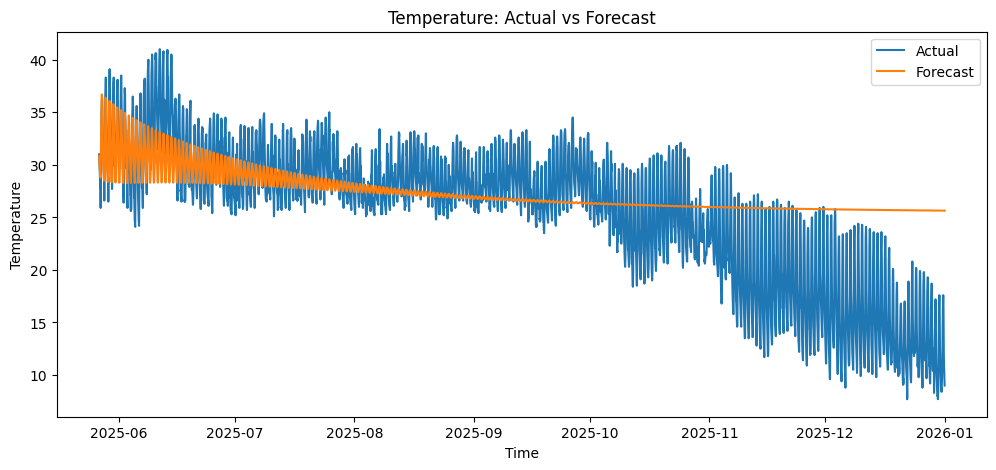

In [23]:
import matplotlib.pyplot as plt

feature = "Temperature"

plt.figure(figsize=(12, 5))

plt.plot(test_data.index, test_data[feature], label="Actual")
plt.plot(test_data.index, forecast_df[feature], label="Forecast")

plt.title(f"{feature}: Actual vs Forecast")
plt.xlabel("Time")
plt.ylabel(feature)
plt.legend()

plt.show()

In [24]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []

for target in weather_data.columns:

    X_train = train_data.drop(columns=[target])
    y_train = train_data[target]

    X_test = test_data.drop(columns=[target])
    y_test = test_data[target]

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append([target, mae, rmse, r2])

evaluation = pd.DataFrame(
    results,
    columns=["Target", "MAE", "RMSE", "R²"]
)

print(evaluation)

                               Target       MAE      RMSE        R²
0                         Temperature  0.489098  0.659707  0.989991
1                   Relative_humidity  2.794829  3.692497  0.953460
2                                Rain  0.257713  0.739962  0.064139
3                    Soil_temperature  0.468884  0.615417  0.990008
4                          Wind_speed  3.262093  4.160409  0.609681
5                    Surface_pressure  0.028511  0.080658  0.999872
6                        Pressure_msl  0.028059  0.079173  0.999888
7                              is_day  0.209121  0.299110  0.642005
8         Rolling Mean of Temperature  0.391170  0.525751  0.991714
9   Rolling Mean of Relative_humidity  2.244585  3.055937  0.928524
10               Rolling Mean of Rain  0.049676  0.128054  0.822277
11   Rolling Mean of Soil_temperature  0.391302  0.522260  0.991536
12         Rolling Mean of Wind_speed  2.422905  2.965257  0.679136
13   Rolling Mean of Surface_pressure  0.035654 

In [25]:
import pandas as pd
import numpy as np

from lightgbm import LGBMRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = []

for target in weather_data.columns:

    X_train = train_data.drop(columns=[target])
    y_train = train_data[target]

    X_test = test_data.drop(columns=[target])
    y_test = test_data[target]

    model = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append([target, mae, rmse, r2])

evaluation = pd.DataFrame(
    results,
    columns=["Target", "MAE", "RMSE", "R²"]
)

print(evaluation)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006455 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4794
[LightGBM] [Info] Number of data points in the train set: 47326, number of used features: 21
[LightGBM] [Info] Start training from score 24.787977
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008993 seconds.
You can set `force_col_wise=t